In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
import sys, xgboost as xgb
print("Python:", sys.executable)
print("xgboost:", xgb.__version__)

Python: C:\Users\Admin\anaconda3\envs\insaml_env\python.exe
xgboost: 2.1.4


In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지

In [4]:

import pandas as pd
import numpy as np

# 원본 CSV 경로
csv_path = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가.csv"

# 변환된 CSV 저장 경로
save_path = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv"

# 데이터 불러오기
try:
    df = pd.read_csv(csv_path)
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, encoding="cp949")

# 환율
USD_TO_KRW = 1350

# 급여 관련 컬럼 자동 탐색 (대소문자 무시)
# 일당, 시급 키워드까지 포함
keywords = ["월급", "연봉", "income", "salary", "급여", "일당", "시급"]
salary_cols = [col for col in df.columns 
               if any(k in col.lower() for k in keywords)]

# 원화 변환 적용
for c in salary_cols:
    if np.issubdtype(df[c].dtype, np.number):
        df[c] = df[c] * USD_TO_KRW
        print(f"[단위 변환] {c}: USD → 원화(KRW) 변환 완료")

# 변환된 데이터 저장
df.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f" 변환 완료! 저장 위치: {save_path}")


[단위 변환] 월급: USD → 원화(KRW) 변환 완료
 변환 완료! 저장 위치: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv


In [5]:
%pip install -q openpyxl

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ===== 0) 경로/설정 =====
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv"   # 파일 경로 확인
OUTDIR    = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피처임포턴스_결과_Label"   # 폴더
TARGET_COL = "업무평가"
DROP_COLS  = ["사번", "학력", "거리", "성인여부"]

os.makedirs(OUTDIR, exist_ok=True)
OUT_CSV = os.path.join(OUTDIR, "feature_importance_label_table.csv")
OUT_PNG = os.path.join(OUTDIR, "feature_importance_label_top30.png")

# ===== 1) 데이터 로드(인코딩 자동 시도 + 컬럼 공백 제거) =====
def read_csv_smart(path):
    for enc in ("utf-8", "cp949"):
        try:
            df = pd.read_csv(path, encoding=enc)
            df.columns = df.columns.str.strip()
            return df
        except Exception:
            continue
    raise FileNotFoundError(f"CSV를 읽을 수 없습니다: {path}")

df = read_csv_smart(INPUT_CSV)
if TARGET_COL not in df.columns:
    raise ValueError(f"'{TARGET_COL}' 컬럼이 없습니다. 실제 컬럼명을 확인하세요. 현재 컬럼들: {df.columns.tolist()}")

# ===== 2) 타깃 매핑(이진) =====
def map_binary(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        uniq = sorted(series.dropna().unique().tolist())
        if len(uniq) != 2:
            raise ValueError(f"이진분류를 위해 '{TARGET_COL}'의 유일값이 2개여야 합니다. 현재: {uniq}")
        lo, hi = uniq[0], uniq[1]
        return series.replace({lo: 0, hi: 1}).astype(int)
    # 문자열 케이스
    s = series.astype(str).str.strip()
    mapping = {"보통":0,"보통(0)":0,"0":0,"좋다":1,"좋음":1,"1":1}
    mapped = s.map(mapping)
    if mapped.isna().any():
        top2 = s.value_counts().index.tolist()[:2]
        if len(top2) == 2:
            auto_map = {top2[0]:0, top2[1]:1}
            mapped = s.map(auto_map)
    if mapped.isna().any():
        raise ValueError(f"'{TARGET_COL}'을(를) 0/1로 매핑 실패. 값 분포 확인 필요.")
    return mapped.astype(int)

y = map_binary(df[TARGET_COL])

# ===== 3) 피처 구성 (제외열 드롭) =====
use_cols = [c for c in df.columns if c not in (DROP_COLS + [TARGET_COL])]
X = df[use_cols].copy()

# dtype 정리 (문자/숫자 자동 판별)
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

# 결측/이상치 처리: 범주형 결측은 '미상', 수치형 결측은 중앙값
cat_transform = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="constant", fill_value="미상")),
    ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])
num_transform = Pipeline(steps=[
    ("to_numeric", SimpleImputer(strategy="median"))
])

pre = ColumnTransformer(
    transformers=[
        ("cat", cat_transform, cat_cols),
        ("num", num_transform, num_cols),
    ],
    remainder="drop"
)

# ===== 4) 모델 (XGBoost 우선, 불가 시 RF 폴백) =====
use_xgb = True
try:
    from xgboost import XGBClassifier
    clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
    )
except Exception:
    use_xgb = False
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(n_estimators=600, random_state=42, n_jobs=-1)

pipe = Pipeline([("pre", pre), ("clf", clf)])

# ===== 5) 전체 데이터로 학습 (임포턴스만 목적) =====
pipe.fit(X, y)

# ===== 6) 피처 이름 (라벨 인코딩이므로 원 컬럼 수와 동일) =====
feature_names = cat_cols + num_cols  # ColumnTransformer 순서: cat -> num

# ===== 7) 중요도 추출 (XGB: gain, RF: impurity) =====
import pandas as pd
if use_xgb:
    booster = pipe.named_steps["clf"].get_booster()
    gain_dict = booster.get_score(importance_type="gain")  # f0,f1,... 키
    mapped = []
    for i, fname in enumerate(feature_names):
        gain = gain_dict.get(f"f{i}", 0.0)
        mapped.append((fname, gain))
    fi_df = pd.DataFrame(mapped, columns=["feature", "importance_gain"]).sort_values("importance_gain", ascending=False)
else:
    importances = pipe.named_steps["clf"].feature_importances_
    fi_df = (pd.DataFrame({"feature": feature_names, "importance_gain": importances})
             .sort_values("importance_gain", ascending=False))

# ===== 8) 저장 & 시각화 =====
fi_df.to_csv(OUT_CSV, index=False)

topk = fi_df.head(30).iloc[::-1]
plt.figure(figsize=(10, 12))
plt.barh(topk["feature"], topk["importance_gain"])  # 색 지정 X(기본)
plt.title("[Label Encoded] Feature Importance (Top 30)" + (" - gain" if use_xgb else ""))
plt.tight_layout()
plt.savefig(OUT_PNG)
plt.close()

print("[완료] 피처 임포턴스 저장")
print(f"- 표 CSV : {OUT_CSV}")
print(f"- 그래프 : {OUT_PNG}")
print("\n상위 20개 미리보기:")
print(fi_df.head(20))


[완료] 피처 임포턴스 저장
- 표 CSV : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피처임포턴스_결과_Label\feature_importance_label_table.csv
- 그래프 : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피처임포턴스_결과_Label\feature_importance_label_top30.png

상위 20개 미리보기:
      feature  importance_gain
1          출장         1.153543
7          야근         1.100912
20        워라밸         1.093830
6        결혼여부         1.042299
2          부서         1.035155
0      회사와의마찰         1.032858
13         월급         1.018055
10     참여프로젝트         1.000000
18         경력         0.979264
19  전년도교육출장횟수         0.976718
11       근속연차         0.966592
14       이직회수         0.956399
3          전공         0.939891
9         만족도         0.936452
5          직급         0.933142
15       주변평가         0.930386
21    현회사근속년수         0.924748
12      직업만족도         0.924538
8          나이         0.921129
17     스톡옵션레벨         0.875684


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ===== 0) 경로/설정 =====
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv"
OUTDIR    = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피어슨상관_결과"
TARGET_COL = "업무평가"
DROP_COLS  = ["사번", "학력", "거리", "성인여부"]

os.makedirs(OUTDIR, exist_ok=True)
OUT_CSV_PEAR  = os.path.join(OUTDIR, "feature_correlation_pearson.csv")
OUT_PNG_PEAR  = os.path.join(OUTDIR, "feature_correlation_top30_pearson.png")

# ===== 1) 데이터 로드 =====
def read_csv_smart(path):
    for enc in ("utf-8", "cp949"):
        try:
            df = pd.read_csv(path, encoding=enc)
            df.columns = df.columns.str.strip()
            return df
        except Exception:
            continue
    raise FileNotFoundError(f"CSV를 읽을 수 없습니다: {path}")

df = read_csv_smart(INPUT_CSV)
if TARGET_COL not in df.columns:
    raise ValueError(f"'{TARGET_COL}' 컬럼이 없습니다. 현재 컬럼들: {df.columns.tolist()}")

# ===== 2) 타깃 매핑(이진) =====
def map_binary(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        uniq = sorted(series.dropna().unique().tolist())
        if len(uniq) != 2:
            raise ValueError(f"이진분류용 타깃 유일값 2개 필요. 현재: {uniq}")
        lo, hi = uniq[0], uniq[1]
        return series.replace({lo:0, hi:1}).astype(int)
    s = series.astype(str).str.strip()
    mapping = {"보통":0,"보통(0)":0,"0":0,"좋다":1,"좋음":1,"1":1}
    m = s.map(mapping)
    if m.isna().any():
        top2 = s.value_counts().index.tolist()[:2]
        if len(top2) == 2:
            m = s.map({top2[0]:0, top2[1]:1})
    if m.isna().any():
        raise ValueError(f"'{TARGET_COL}' 0/1 매핑 실패. 값 분포 확인.")
    return m.astype(int)

y = map_binary(df[TARGET_COL])

# ===== 3) 피처 구성 (제외열 드롭) =====
use_cols = [c for c in df.columns if c not in (DROP_COLS + [TARGET_COL])]
X = df[use_cols].copy()

# ===== 4) 전처리 (라벨 인코딩/결측 처리) =====
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

cat_transform = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="constant", fill_value="미상")),
    ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])
num_transform = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median"))
])

pre = ColumnTransformer(
    transformers=[
        ("cat", cat_transform, cat_cols),
        ("num", num_transform, num_cols),
    ],
    remainder="drop"
)

# ===== 5) 전처리 적용 & Pearson 계산 =====
X_t = pre.fit_transform(X)                 # numpy array
feature_names = cat_cols + num_cols        # ColumnTransformer 순서(cat -> num)
X_proc = pd.DataFrame(X_t, columns=feature_names, index=X.index)

df_corr = pd.concat([X_proc, y.rename(TARGET_COL)], axis=1)

pear = df_corr.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).to_frame(name="pearson")
pear["abs_pearson"] = pear["pearson"].abs()
pear = pear.sort_values("abs_pearson", ascending=False)

# ===== 6) 저장 =====
pear.to_csv(OUT_CSV_PEAR, encoding="utf-8-sig")

# ===== 7) 시각화(Top-30, 값 라벨 표시) =====
top = pear["pearson"].abs().head(30).iloc[::-1]  # 작은값 아래, 큰값 위
plt.figure(figsize=(12, 9))
bars = plt.barh(top.index, top.values)  # 색상 기본값 사용
plt.title("[Pearson] Feature-Target Correlation (Top 30)")
plt.xlabel("Absolute Pearson Correlation")

# 막대에 수치 라벨 달기
for b in bars:
    w = b.get_width()
    plt.text(w + 0.0005, b.get_y() + b.get_height()/2, f"{w:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_PNG_PEAR)
plt.close()

print("[완료] Pearson 상관계수 저장")
print(f"- CSV : {OUT_CSV_PEAR}")
print(f"- PNG : {OUT_PNG_PEAR}")
print("\n[상위 15개 미리보기]")
print(pear.head(15))


[완료] Pearson 상관계수 저장
- CSV : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피어슨상관_결과\feature_correlation_pearson.csv
- PNG : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피어슨상관_결과\feature_correlation_top30_pearson.png

[상위 15개 미리보기]
            pearson  abs_pearson
부서        -0.032669     0.032669
주변평가      -0.031351     0.031351
만족도       -0.029548     0.029548
참여프로젝트    -0.029071     0.029071
근속연차      -0.021222     0.021222
월급        -0.017120     0.017120
전년도교육출장횟수 -0.015579     0.015579
이직회수      -0.014095     0.014095
성별        -0.013859     0.013859
전공         0.011973     0.011973
직급         0.008582     0.008582
경력         0.006744     0.006744
결혼여부       0.005207     0.005207
야근         0.004369     0.004369
스톡옵션레벨     0.003506     0.003506


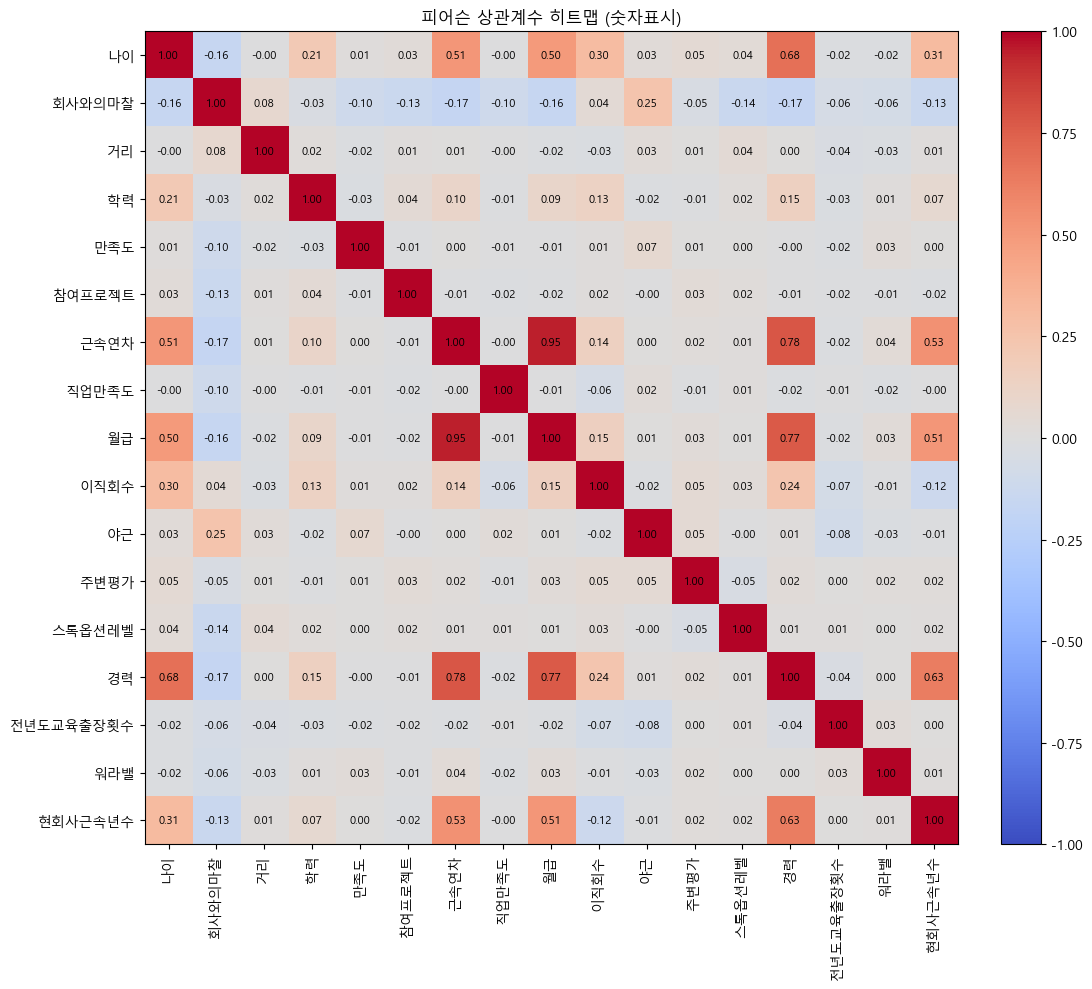

In [8]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 0) 유틸: Yes/No → 1/0, 숫자로 변환
# =========================================
def prepare_numeric_for_corr(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()

    # 공백 제거 및 문자열 소문자 정규화
    for c in df2.select_dtypes(include=['object', 'string']).columns:
        df2[c] = df2[c].astype(str).str.strip()

    # (A) Yes/No 이진 컬럼 자동 인코딩 (대소문자/공백 허용)
    def is_yesno_col(s: pd.Series) -> bool:
        vals = set(s.dropna().str.lower().unique())
        return vals.issubset({'yes', 'no'}) and len(vals) > 0

    for c in df2.select_dtypes(include=['object', 'string']).columns:
        s = df2[c].astype(str)
        if is_yesno_col(s):
            df2[c] = s.str.lower().map({'yes': 1, 'no': 0})

    # (B) 숫자로 바꿀 수 있는 문자열은 숫자로 강제 변환
    for c in df2.columns:
        if df2[c].dtype == 'object' or df2[c].dtype.name == 'string':
            df2[c] = pd.to_numeric(df2[c], errors='coerce')

    # (C) 상수(분산 0) 컬럼 제거 (상관계수 NaN 방지)
    num = df2.select_dtypes(include=[np.number])
    nunique = num.nunique(dropna=True)
    num = num.loc[:, nunique > 1]

    return num

# =========================================
# 1) (선택) 불필요 컬럼 드롭
# =========================================
# 예: 식별자/텍스트 등
drop_cols = ['사번', '이름', '메모']  # 있으면 지우고, 없으면 무시
df = df.drop(columns=drop_cols, errors='ignore')

# (선택) 타깃이 범주형(KR 텍스트)이면 숫자로 맵핑해서 상관 포함하고 싶을 때 예시:
# if '업무평가' in df.columns and df['업무평가'].dtype == 'object':
#     df['업무평가'] = df['업무평가'].map({'보통': 0, '좋다': 1, '좋음': 1})

# =========================================
# 2) 숫자형만 남겨 피어슨 상관 계산
# =========================================
num = prepare_numeric_for_corr(df)
corr = num.corr(method='pearson')

# =========================================
# 3) 히트맵(피어슨, 숫자 표시) + 저장
# =========================================
plt.figure(figsize=(12, 10))
im = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)

# 축 라벨
plt.xticks(ticks=np.arange(corr.shape[1]), labels=corr.columns, rotation=90)
plt.yticks(ticks=np.arange(corr.shape[0]), labels=corr.index)

# 각 타일에 수치(annotation)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.values[i, j]
        if not np.isnan(v):
            plt.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=8)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("피어슨 상관계수 히트맵 (숫자표시)")
plt.tight_layout()
plt.savefig("corr_heatmap_pearson.png", dpi=200)
plt.show()


In [9]:
import pandas as pd
from pathlib import Path
import numpy as np

# ====== 경로 설정 ======
INPUT_CSV  = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv"
OUTPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv"

# ====== 안전 나눗셈 ======
def safe_div_series(a: pd.Series, b: pd.Series) -> pd.Series:
    """Series 간 안전 나눗셈(0으로 나누기 -> <NA>)"""
    b_ = pd.to_numeric(b, errors="coerce").copy()
    b_.replace(0, np.nan, inplace=True)
    return pd.to_numeric(a, errors="coerce") / b_

# ====== 로드 ======
df = pd.read_csv(INPUT_CSV)

# ====== [중요] 사용 제외 피처 선제 제거 ======
EXCLUDE_COLS = [
    "직업만족도", "워라밸", "회사와의마찰",       # 주관적/설문
    "사번", "성별",                           # 식별 위험
    "결혼여부", "직급", "전공", "부서",         # 범주/식별성 강함
    "근무기준시간",                            # 고정/의미 약함
    "스톡옵션레벨",                           # 주관/해석 가변
    "성인여부", "학력", "거리", "야근", "만족도" # 기타
]
drop_targets = [c for c in EXCLUDE_COLS if c in df.columns]
df = df.drop(columns=drop_targets, errors="ignore")

print("[제외된 피처]")
for c in drop_targets:
    print(" -", c)

# ====== 파생변수에 필요한 원천 컬럼 확인 ======
required = [
    "출장", "이직회수", "참여프로젝트", "월급", "경력", "전년도교육출장횟수",
    "현회사근속년수", "나이", "주변평가", "근속연차"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"다음 컬럼이 CSV에 없습니다: {missing}")

# ====== (추가) '출장' 고정 인코딩(0/1/2) ======
def normalize_travel(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()

    # 대표 표기 매핑
    if s in ["0회", "0", "0.0", "Non-Travel", "non-travel", "non travel"]:
        return 0
    if s in ["1~29회", "1~29", "Travel_Rarely", "travel_rarely", "rarely"]:
        return 1
    if s in ["30회 이상", "30이상", ">=30", "30+", "Travel_Frequently", "travel_frequently", "frequently"]:
        return 2

    # 숫자 → 구간화 (예: 0, 15, 30)
    try:
        v = float(s)
        if v <= 0:
            return 0
        elif v < 30:
            return 1
        else:
            return 2
    except:
        return np.nan

# ====== 숫자형 캐스팅(출장은 제외!) ======
numeric_required = [c for c in required if c != "출장"]
for c in numeric_required:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 고정 인코딩 컬럼 생성 (원본 '출장' 보존)
df["출장_등급"] = df["출장"].apply(normalize_travel).astype("Int64")

# ====== 파생변수 15개 ======
# 1) 비율(Ratio)
df["이직률"]             = safe_div_series(df["이직회수"], df["경력"])
df["프로젝트참여율"]       = safe_div_series(df["참여프로젝트"], df["경력"])
df["교육출장참여율"]       = safe_div_series(df["전년도교육출장횟수"], df["경력"])
df["현직근속비율"]         = safe_div_series(df["현회사근속년수"], df["경력"])
df["연봉/경력비율"]        = safe_div_series(df["월급"], df["경력"])
df["연봉/프로젝트비율"]     = safe_div_series(df["월급"], df["참여프로젝트"])

# 2) 차이(Difference)
df["경력-근속연차"]        = df["경력"] - df["근속연차"]
df["근속연차차이"]         = df["근속연차"] - df["현회사근속년수"]

# 3) 복합지표(Composite)
df["프로젝트밀도지수"]      = safe_div_series(df["참여프로젝트"] + df["전년도교육출장횟수"], df["경력"])
df["평판×근속연차"]         = pd.to_numeric(df["주변평가"], errors="coerce") * pd.to_numeric(df["근속연차"], errors="coerce")
df["연봉×평판점수"]         = pd.to_numeric(df["월급"], errors="coerce") * pd.to_numeric(df["주변평가"], errors="coerce")

# 4) 나이 기반
df["경력/나이비율"]        = safe_div_series(df["경력"], df["나이"])
df["근속/나이비율"]        = safe_div_series(df["근속연차"], df["나이"])
df["연봉/나이"]            = safe_div_series(df["월급"], df["나이"])
df["입사나이"]             = pd.to_numeric(df["나이"], errors="coerce") - pd.to_numeric(df["경력"], errors="coerce")

# ====== 값 정리 ======
# inf/-inf → NaN
df.replace([float("inf"), float("-inf")], np.nan, inplace=True)

# (요청 반영) 비율형 컬럼 NaN → 0 대체
zero_fill_cols = [
    "이직률", "프로젝트참여율", "교육출장참여율",
    "현직근속비율", "연봉/경력비율", "프로젝트밀도지수"
]
for c in zero_fill_cols:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# ※ 필요하면 전체 NaN을 0으로 대체 (옵션)
# df = df.fillna(0)

# ====== 저장 ======
Path(OUTPUT_CSV).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print("\n[파생변수 생성 완료]")
print(f"저장 경로: {OUTPUT_CSV}")
print("\n[생성된 파생 컬럼 15개 + 출장_등급]")
new_cols = [
    "이직률","프로젝트참여율","교육출장참여율","현직근속비율","연봉/경력비율","연봉/프로젝트비율",
    "경력-근속연차","근속연차차이",
    "프로젝트밀도지수","평판×근속연차","연봉×평판점수",
    "경력/나이비율","근속/나이비율","연봉/나이","입사나이",
    "출장_등급"
]
print(new_cols)

# 디버그: 출장 범주 분포 확인
if "출장_등급" in df.columns:
    print("\n[출장_등급 분포]")
    print(df["출장_등급"].value_counts(dropna=False).sort_index())


[제외된 피처]
 - 직업만족도
 - 워라밸
 - 회사와의마찰
 - 사번
 - 성별
 - 결혼여부
 - 직급
 - 전공
 - 부서
 - 근무기준시간
 - 스톡옵션레벨
 - 성인여부
 - 학력
 - 거리
 - 야근
 - 만족도

[파생변수 생성 완료]
저장 경로: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv

[생성된 파생 컬럼 15개 + 출장_등급]
['이직률', '프로젝트참여율', '교육출장참여율', '현직근속비율', '연봉/경력비율', '연봉/프로젝트비율', '경력-근속연차', '근속연차차이', '프로젝트밀도지수', '평판×근속연차', '연봉×평판점수', '경력/나이비율', '근속/나이비율', '연봉/나이', '입사나이', '출장_등급']

[출장_등급 분포]
출장_등급
0     150
1    1043
2     277
Name: count, dtype: Int64


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ====== 경로 설정 ======
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv"
OUTDIR    = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\newfeature_feature_importance"
Path(OUTDIR).mkdir(parents=True, exist_ok=True)

# ====== 데이터 로드 ======
df = pd.read_csv(INPUT_CSV)

# ====== 타깃 선택(업무평가2 우선, 없으면 업무평가) ======
if "업무평가2" in df.columns:
    target_col = "업무평가2"
elif "업무평가" in df.columns:
    target_col = "업무평가"
else:
    raise ValueError("타깃 컬럼('업무평가2' 또는 '업무평가')을 찾을 수 없습니다.")

# ====== 타깃 0/1 명시 변환 ======
def map_binary_target(series: pd.Series) -> pd.Series:
    # 1) 숫자형이면 유일값 2개를 0/1로 정규화
    if pd.api.types.is_numeric_dtype(series):
        uniq = pd.Series(series.dropna().unique()).sort_values().tolist()
        if len(uniq) != 2:
            raise ValueError(f"이진분류를 위해 '{series.name}'의 유일값이 2개여야 합니다. 현재: {uniq}")
        lo, hi = uniq[0], uniq[1]
        return series.replace({lo: 0, hi: 1}).astype(int)

    # 2) 문자열 매핑 (보통/좋다/좋음/0/1 등)
    s = series.astype(str).str.strip()
    mapping = {"보통":0, "보통(0)":0, "0":0, "좋다":1, "좋음":1, "1":1}
    mapped = s.map(mapping)

    # 3) 매핑 실패 시, 상위 2개 빈도값을 0/1로 자동 매핑
    if mapped.isna().any():
        top2 = s.value_counts().index.tolist()[:2]
        if len(top2) == 2:
            auto_map = {top2[0]:0, top2[1]:1}
            mapped = s.map(auto_map)

    if mapped.isna().any():
        bad = s[mapped.isna()].unique()[:10]
        raise ValueError(f"'{series.name}' 0/1 매핑 실패. 값 예시: {bad}")

    return mapped.astype(int)

y = map_binary_target(df[target_col])

# ====== 원본 '출장'은 제거, '출장_등급'만 사용 ======
if "출장" in df.columns:
    df = df.drop(columns=["출장"])
if "출장_등급" not in df.columns:
    print("[경고] '출장_등급' 컬럼이 없습니다. 이전 단계(피처 생성)에서 생성되었는지 확인하세요.")

# ====== 숫자형 피처 자동 선택 (타깃 제외) ======
df_numeric = df.copy()
for c in df_numeric.columns:
    if c == target_col:
        continue
    df_numeric[c] = pd.to_numeric(df_numeric[c], errors="coerce")

# 무한대 처리 → NaN, 타깃 결측 제거(혹시 모를 누락 방지)
df_numeric.replace([np.inf, -np.inf], np.nan, inplace=True)
df_numeric = df_numeric.dropna(subset=[target_col])

# X, y 분리 (y는 이미 0/1 시리즈 y 사용)
X = df_numeric.drop(columns=[target_col]).copy()  # 주의: 여기 y를 다시 사용
# 전부 NaN인 열 제거
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print("[안내] 전부 NaN이라 제거된 열:", all_nan_cols)
    X = X.drop(columns=all_nan_cols)

# 결측치 간단 대체(정확도 중심: 0 대체)
X = X.fillna(0)

# ====== 데이터 분할 ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y.loc[X.index], test_size=0.2, random_state=42, stratify=y.loc[X.index] if y.nunique() > 1 else None
)

# ====== 모델 학습 (RandomForest - 정확도 우선) ======
clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

# 성능 확인
pred = clf.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"[Test Accuracy] {acc:.4f}")

# ====== 피처 중요도 산출 ======
importances = clf.feature_importances_
fi = (pd.DataFrame({"feature": X.columns, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True))

# 누적 기여도
fi["cum_importance"] = fi["importance"].cumsum()

# 저장(CSV)
fi_csv = os.path.join(OUTDIR, "feature_importance_rf.csv")
fi.to_csv(fi_csv, index=False, encoding="utf-8-sig")
print(f"[저장] {fi_csv}")

# ====== 시각화: 상위 K개 바차트 ======
TOP_K = min(20, len(fi))
fi_top = fi.head(TOP_K).copy()

plt.figure(figsize=(10, 6))
plt.barh(fi_top["feature"][::-1], fi_top["importance"][::-1])
plt.xlabel("Importance")
plt.title(f"RandomForest Feature Importance (Top {TOP_K})\nAcc={acc:.3f}")
plt.tight_layout()
bar_png = os.path.join(OUTDIR, "feature_importance_bar.png")
plt.savefig(bar_png, dpi=150)
plt.close()
print(f"[저장] {bar_png}")

# ====== 시각화 1: 누적 기여도(X축=인덱스) ======
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(fi)+1), fi["cum_importance"], marker="o")
plt.axhline(0.8, linestyle="--")
plt.xlabel("Number of Features (sorted)")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance (Index Axis)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
cumsum_index_png = os.path.join(OUTDIR, "feature_importance_cumsum_index.png")
plt.savefig(cumsum_index_png, dpi=150)
plt.close()
print(f"[저장] {cumsum_index_png}")

# ====== 시각화 2: 누적 기여도(X축=피처명) ======
plt.figure(figsize=(12, 5))
plt.plot(fi["feature"], fi["cum_importance"], marker="o")
plt.axhline(0.8, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Feature")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance (Feature Axis)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
cumsum_feature_png = os.path.join(OUTDIR, "feature_importance_cumsum_feature.png")
plt.savefig(cumsum_feature_png, dpi=150)
plt.close()
print(f"[저장] {cumsum_feature_png}")

# ====== 누적 80% 도달 지점 출력 ======
idx_80 = (fi["cum_importance"] >= 0.8).idxmax() + 1  # 1-index
print(f"[안내] 누적 80%에 도달하는 최소 피처 개수: {idx_80}")
print("상위 피처(예시):", fi.head(min(10, len(fi)))["feature"].tolist())

# ====== [추가 진단] 출장_등급 임포턴스 & 등급별 '좋다'(1) 비율 ======
if "출장_등급" in X.columns:
    imp_row = fi.loc[fi["feature"] == "출장_등급", "importance"]
    if not imp_row.empty:
        print(f"[참고] '출장_등급' importance: {imp_row.iloc[0]:.6f}")
    else:
        print("[참고] '출장_등급'이 학습 피처에 포함되지 않았습니다.")

    # 원본 df 기준으로 등급별 '좋다' 비율(=y 평균) 확인
    tmp = df.copy()
    tmp["_y01"] = y.values  # 0=보통, 1=좋다
    if tmp["출장_등급"].notna().any():
        grade_mean = tmp.groupby("출장_등급")["_y01"].mean().sort_index()
        print("\n[출장_등급별 '좋다'(1) 비율]\n", grade_mean)
        print(f"[진단] 등급↑ -> 비율 {'단조증가' if grade_mean.is_monotonic_increasing else '단조증가 아님'}")
else:
    print("[참고] '출장_등급' 컬럼이 없어 등급별 분석을 생략합니다.")


[Test Accuracy] 0.8469
[저장] C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\newfeature_feature_importance\feature_importance_rf.csv
[저장] C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\newfeature_feature_importance\feature_importance_bar.png
[저장] C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\newfeature_feature_importance\feature_importance_cumsum_index.png
[저장] C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\newfeature_feature_importance\feature_importance_cumsum_feature.png
[안내] 누적 80%에 도달하는 최소 피처 개수: 16
상위 피처(예시): ['연봉/프로젝트비율', '연봉/나이', '연봉/경력비율', '월급', '연봉×평판점수', '경력/나이비율', '근속/나이비율', '나이', '프로젝트밀도지수', '교육출장참여율']
[참고] '출장_등급' importance: 0.017615

[출장_등급별 '좋다'(1) 비율]
 출장_등급
0    0.173333
1    0.147651
2    0.166065
Name: _y01, dtype: float64
[진단] 등급↑ -> 비율 단조증가 아님


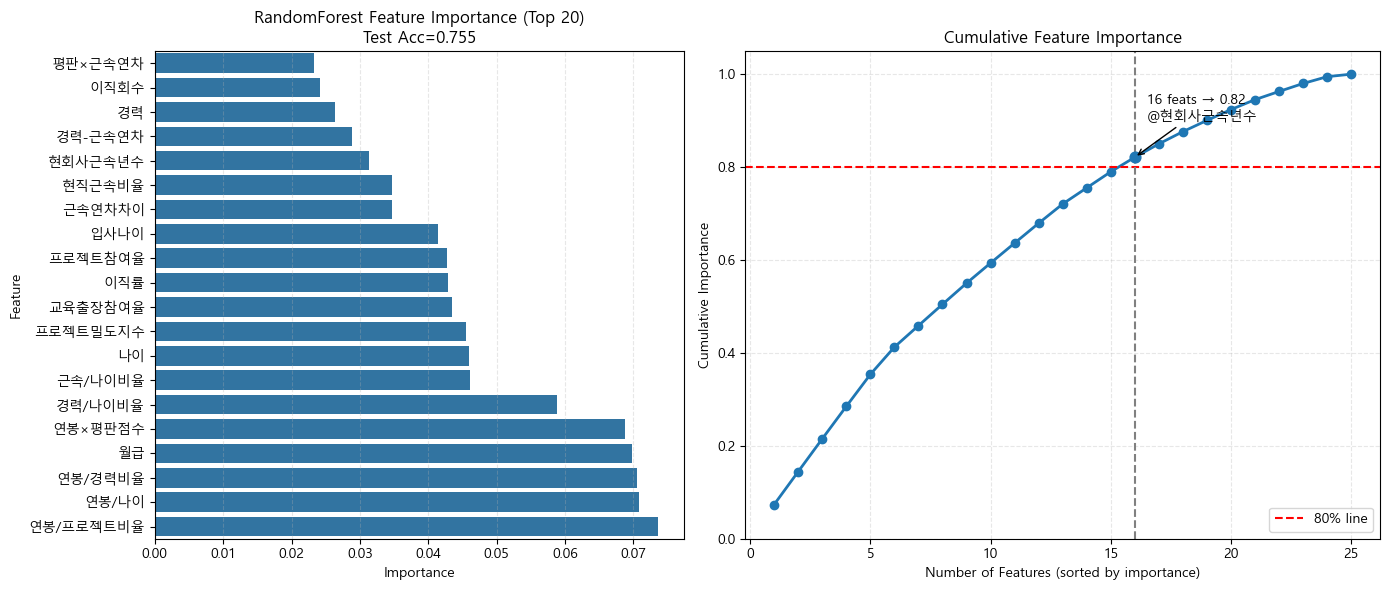

[저장] C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과_BorderlineSMOTE_normal\feature_importance_combo.png


In [17]:
# === 피처 중요도 시각화 (Top-K 바차트 + 누적 기여도 한 화면) ===
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance_combo(fi: pd.DataFrame, acc: float, outdir: str, top_k: int = 20):
    """
    fi: columns = ['feature', 'importance'] (이미 importance 내림차순 정렬 권장)
    acc: 테스트 정확도 (그래프 타이틀 표기용)
    outdir: 저장 폴더
    top_k: 상위 K개 피처 표시
    """
    os.makedirs(outdir, exist_ok=True)

    # 정렬 보장 + 누적 기여도 계산
    fi = fi.sort_values("importance", ascending=False).reset_index(drop=True).copy()
    fi["cum_importance"] = fi["importance"].cumsum()
    fi["rank"] = np.arange(1, len(fi) + 1)

    # Top-K
    top_k = min(top_k, len(fi))
    fi_top = fi.head(top_k)

    # 80% 지점
    idx80 = int((fi["cum_importance"] >= 0.8).idxmax())  # 0-index
    feat80 = fi.loc[idx80, "feature"]
    cum80  = fi.loc[idx80, "cum_importance"]
    rank80 = fi.loc[idx80, "rank"]

    # ---- 그리기 ----
    plt.figure(figsize=(14, 6))
    gs = plt.GridSpec(1, 2, width_ratios=[1, 1.2])

    # (좌) Top-K 바차트
    ax0 = plt.subplot(gs[0])
    sns.barplot(x="importance", y="feature", data=fi_top.iloc[::-1], ax=ax0)  # 위가 큰 값 오도록 역순
    ax0.set_title(f"RandomForest Feature Importance (Top {top_k})\nTest Acc={acc:.3f}")
    ax0.set_xlabel("Importance")
    ax0.set_ylabel("Feature")
    ax0.grid(axis="x", linestyle="--", alpha=0.3)

    # (우) 누적 기여도
    ax1 = plt.subplot(gs[1])
    ax1.plot(fi["rank"], fi["cum_importance"], marker="o", linewidth=2)
    ax1.axhline(0.8, linestyle="--", color="red", label="80% line")
    ax1.axvline(rank80, linestyle="--", color="gray")
    ax1.scatter([rank80], [cum80], s=60, zorder=3)
    ax1.annotate(f"{rank80} feats → {cum80:.2f}\n@{feat80}",
                 xy=(rank80, cum80),
                 xytext=(rank80+0.5, min(0.98, cum80+0.08)),
                 arrowprops=dict(arrowstyle="->", lw=1))
    ax1.set_xlabel("Number of Features (sorted by importance)")
    ax1.set_ylabel("Cumulative Importance")
    ax1.set_title("Cumulative Feature Importance")
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, linestyle="--", alpha=0.3)
    ax1.legend(loc="lower right")

    plt.tight_layout()
    out_png = os.path.join(outdir, "feature_importance_combo.png")
    plt.savefig(out_png, dpi=150)
    plt.show()
    print(f"[저장] {out_png}")

# 사용 예시 (당신 코드 바로 아래에 추가해서 실행)
plot_feature_importance_combo(fi=fi, acc=acc, outdir=OUTDIR, top_k=20)


In [22]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import BorderlineSMOTE
import xgboost as xgb

# =============================
# 0) 설정 (토글)
# =============================
USE_SMOTE = False                # 초기 기준선: False (필요시 True)
THRESHOLD_POLICY = "default"     # "default" (0.5) | "val_acc" (검증 정확도 최대 임계값 사용)

# =============================
# 경로
# =============================
CANDIDATES = [r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv"]
INPATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
assert INPATH is not None, f"입력 CSV를 찾을 수 없습니다. 확인: {CANDIDATES}"

OUTDIR = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과_NATURAL"
Path(OUTDIR).mkdir(parents=True, exist_ok=True)

# =============================
# 1) 데이터 로드 & 타깃
# =============================
df = pd.read_csv(INPATH)

target_col = "업무평가2" if "업무평가2" in df.columns else "업무평가"
assert target_col in df.columns, f"타깃 컬럼 '{target_col}' 없음."

y_raw = df[target_col]
y = (y_raw.replace({"보통":0, "좋다":1, "좋음":1}) if y_raw.dtype=="O" else y_raw).astype(int)

# =============================
# 2) X 구성 (간단 전처리)
# =============================
drop_cols = {target_col, "사번", "학력", "성인여부"}
use_cols = [c for c in df.columns if c not in drop_cols]

num_cols = [c for c in use_cols if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = []
if "출장" in use_cols and not pd.api.types.is_numeric_dtype(df["출장"]):
    cat_cols.append("출장")

X_raw = df[sorted(set(num_cols + cat_cols))].copy()

# =============================
# 3) 데이터 분할 (index 추적)
# =============================
idx = X_raw.index.to_numpy()
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
idx_tr, idx_val = train_test_split(idx_tr, test_size=0.2, random_state=42, stratify=y.iloc[idx_tr])

X_tr_raw, X_val_raw, X_te_raw = X_raw.loc[idx_tr], X_raw.loc[idx_val], X_raw.loc[idx_te]
y_tr, y_val, y_te = y.iloc[idx_tr], y.iloc[idx_val], y.iloc[idx_te]

# =============================
# 4) 전처리 (train에만 fit)
# =============================
transformers = []
if num_cols:
    transformers.append(("num", "passthrough", num_cols))
if cat_cols:
    oe = OrdinalEncoder(
        categories=[["0회","1~29회","30회 이상"]],
        handle_unknown="use_encoded_value", unknown_value=-1
    )
    transformers.append(("cat_trip", oe, cat_cols))

ct = ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)
X_tr = ct.fit_transform(X_tr_raw)
X_val = ct.transform(X_val_raw)
X_te  = ct.transform(X_te_raw)

try:
    feat_names = ct.get_feature_names_out()
except Exception:
    feat_names = np.array(list(X_tr_raw.columns))

# =============================
# 5) (선택) 경계SMOTE - train만
# =============================
if USE_SMOTE:
    bsmote = BorderlineSMOTE(kind='borderline-1', random_state=42)
    X_tr, y_tr = bsmote.fit_resample(X_tr, y_tr)

# =============================
# 6) 모델 학습 (자연스러운 방식)
#    - 휴리스틱 가중치/특이 임계값 신호 제거
#    - 필요시 class_weight 사용(여기선 off)
# =============================
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_te,  label=y_te)

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "eta": 0.05,
    "max_depth": 5,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "lambda": 1.0,
    "min_child_weight": 1.0,
    "scale_pos_weight": 1.0,   # SMOTE off 시 class_weight 대용으로 튜닝 가능(>1)
    "seed": 42,
    "tree_method": "hist",
}
watchlist = [(dtrain, "train"), (dval, "eval")]
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=watchlist,
    early_stopping_rounds=80,
    verbose_eval=False
)

# =============================
# 7) 임계값 결정 (버전 호환)
# =============================
best_iter = getattr(bst, "best_iteration", None)
if best_iter is not None:
    val_proba = bst.predict(dval, iteration_range=(0, best_iter + 1))
    test_proba = bst.predict(dtest, iteration_range=(0, best_iter + 1))
else:
    val_proba = bst.predict(dval)
    test_proba = bst.predict(dtest)

# 임계값 정책에 따라 thr 설정
if THRESHOLD_POLICY == "val_acc":
    thr_grid = np.round(np.linspace(0.20, 0.99, 160), 3)
    best_thr, best_acc = 0.5, -1
    for t in thr_grid:
        y_hat = (val_proba >= t).astype(int)
        acc = accuracy_score(y_val, y_hat)
        if acc > best_acc:
            best_acc, best_thr = acc, t
    thr = best_thr
else:
    thr = 0.5

# 테스트셋 예측
y_pred_te = (test_proba >= thr).astype(int)



# =============================
# 8) 평가 & 저장
# =============================
print(f"[Test] threshold={thr:.3f}")
print(classification_report(y_te, y_pred_te, digits=4))

acc   = accuracy_score(y_te, y_pred_te)
precw = precision_score(y_te, y_pred_te, average="weighted", zero_division=0)
recw  = recall_score(y_te, y_pred_te, average="weighted", zero_division=0)
f1w   = f1_score(y_te, y_pred_te, average="weighted", zero_division=0)
prec1 = precision_score(y_te, y_pred_te, pos_label=1, zero_division=0)
rec1  = recall_score(y_te, y_pred_te, pos_label=1, zero_division=0)

print(f"[Test] accuracy={acc:.4f} | weighted_precision={precw:.4f} | weighted_recall={recw:.4f} | weighted_f1={f1w:.4f}")
print(f"[Test] precision(좋다)={prec1:.4f} | recall(좋다)={rec1:.4f}")

# ROC & 혼동행렬
try:
    auc = roc_auc_score(y_te, test_proba)
except Exception:
    auc = np.nan

fpr, tpr, _ = roc_curve(y_te, test_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve (Test)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "roc_curve.png"), dpi=150)
plt.close()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_te, y_pred_te)
fig, ax = plt.subplots()
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1]).plot(ax=ax, values_format="d", colorbar=False)
ax.set_title(f"Confusion Matrix (thr={thr:.3f})")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "confusion_matrix.png"), dpi=150)
plt.close()

# 예측 결과 저장
preds = pd.DataFrame({"y_true": y_te.values, "p_good": test_proba, "y_pred": y_pred_te}, index=idx_te)
preds_out = pd.concat([df.loc[idx_te, X_raw.columns], preds], axis=1)
preds_out.to_csv(os.path.join(OUTDIR, "preds.csv"), index=False, encoding="utf-8-sig")

print(f"\n[저장완료] 폴더: {OUTDIR}")
print(" - roc_curve.png")
print(" - confusion_matrix.png")
print(" - preds.csv")


[Test] threshold=0.500
              precision    recall  f1-score   support

           0     0.8469    1.0000    0.9171       249
           1     0.0000    0.0000    0.0000        45

    accuracy                         0.8469       294
   macro avg     0.4235    0.5000    0.4586       294
weighted avg     0.7173    0.8469    0.7768       294

[Test] accuracy=0.8469 | weighted_precision=0.7173 | weighted_recall=0.8469 | weighted_f1=0.7768
[Test] precision(좋다)=0.0000 | recall(좋다)=0.0000

[저장완료] 폴더: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과_NATURAL
 - roc_curve.png
 - confusion_matrix.png
 - preds.csv


In [11]:
# import os, warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import OrdinalEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,
#     roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
# )

# import xgboost as xgb

# # -----------------------------
# # 0) 경로
# # -----------------------------
# CANDIDATES = [r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv"]
# INPATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
# assert INPATH is not None, f"입력 CSV를 찾을 수 없습니다. 확인: {CANDIDATES}"

# OUTDIR = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과"
# os.makedirs(OUTDIR, exist_ok=True)

# # -----------------------------
# # 1) 데이터 로드 & 타깃
# # -----------------------------
# df = pd.read_csv(INPATH)

# target_col = "업무평가2" if "업무평가2" in df.columns else "업무평가"
# assert target_col in df.columns, f"타깃 컬럼 '{target_col}' 없음."

# y_raw = df[target_col]
# y = (y_raw.replace({"보통":0,"좋다":1,"좋음":1}) if y_raw.dtype=="O" else y_raw).astype(int)

# # -----------------------------
# # 2) X 구성 (간단 전처리)
# # -----------------------------
# drop_cols = {target_col, "사번", "학력", "성인여부"}  # 필요시 추가
# use_cols = [c for c in df.columns if c not in drop_cols]

# num_cols = [c for c in use_cols if pd.api.types.is_numeric_dtype(df[c])]
# cat_cols = []
# if "출장" in use_cols and not pd.api.types.is_numeric_dtype(df["출장"]):
#     cat_cols.append("출장")

# X_raw = df[sorted(set(num_cols + cat_cols))].copy()

# # -----------------------------
# # 3) 데이터 분할 (index 추적)
# # -----------------------------
# idx = X_raw.index.to_numpy()
# idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
# idx_tr, idx_val = train_test_split(idx_tr, test_size=0.2, random_state=42, stratify=y.iloc[idx_tr])

# X_tr_raw, X_val_raw, X_te_raw = X_raw.loc[idx_tr], X_raw.loc[idx_val], X_raw.loc[idx_te]
# y_tr, y_val, y_te = y.iloc[idx_tr], y.iloc[idx_val], y.iloc[idx_te]

# # -----------------------------
# # 4) 전처리 파이프라인 (train에만 fit)
# # -----------------------------
# transformers = []
# if num_cols:
#     transformers.append(("num", "passthrough", num_cols))
# if cat_cols:
#     oe = OrdinalEncoder(
#         categories=[["0회","1~29회","30회 이상"]],
#         handle_unknown="use_encoded_value", unknown_value=-1
#     )
#     transformers.append(("cat_trip", oe, cat_cols))

# ct = ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)
# X_tr = ct.fit_transform(X_tr_raw)
# X_val = ct.transform(X_val_raw)
# X_te = ct.transform(X_te_raw)

# # -----------------------------
# # 5) 클래스 불균형 보정
# # -----------------------------
# pos = int((y_tr == 1).sum())
# neg = int((y_tr == 0).sum())
# spw = float(neg) / float(pos) if pos > 0 else 1.0

# # -----------------------------
# # 6) XGBoost 학습
# # -----------------------------
# dtrain = xgb.DMatrix(X_tr, label=y_tr)
# dval   = xgb.DMatrix(X_val, label=y_val)
# dtest  = xgb.DMatrix(X_te,  label=y_te)

# params = {
#     "objective": "binary:logistic",
#     "eval_metric": "logloss",
#     "eta": 0.05,
#     "max_depth": 5,
#     "subsample": 0.9,
#     "colsample_bytree": 0.9,
#     "lambda": 1.0,
#     "min_child_weight": 1.0,
#     "scale_pos_weight": spw,
#     "seed": 42
# }

# try:
#     params_with_hist = {**params, "tree_method": "hist"}
#     watchlist = [(dtrain, "train"), (dval, "eval")]
#     bst = xgb.train(
#         params=params_with_hist,
#         dtrain=dtrain,
#         num_boost_round=1000,
#         evals=watchlist,
#         early_stopping_rounds=50,
#         verbose_eval=False
#     )
# except xgb.core.XGBoostError:
#     watchlist = [(dtrain, "train"), (dval, "eval")]
#     bst = xgb.train(
#         params=params,
#         dtrain=dtrain,
#         num_boost_round=1000,
#         evals=watchlist,
#         early_stopping_rounds=50,
#         verbose_eval=False
#     )

# # -----------------------------
# # 7) 임계값 탐색 (Test precision(좋다) ≈ 0.5, recall 무시)
# # -----------------------------
# if hasattr(bst, "best_ntree_limit") and bst.best_ntree_limit:
#     test_proba = bst.predict(dtest, ntree_limit=bst.best_ntree_limit)
# else:
#     test_proba = bst.predict(dtest)

# thr_grid = np.round(np.linspace(0.20, 0.99, 160), 3)  # 좀 더 세밀하게
# target_precision = 0.5
# best_thr = None
# closest_diff = 1.0

# for t in thr_grid:
#     y_pred_test = (test_proba >= t).astype(int)
#     prec1 = precision_score(y_te, y_pred_test, pos_label=1, zero_division=0)
#     diff = abs(prec1 - target_precision)
#     if diff < closest_diff:
#         closest_diff = diff
#         best_thr = t

# y_pred_te = (test_proba >= best_thr).astype(int)

# acc   = accuracy_score(y_te, y_pred_te)
# precw = precision_score(y_te, y_pred_te, average="weighted", zero_division=0)
# recw  = recall_score(y_te, y_pred_te, average="weighted", zero_division=0)
# f1w   = f1_score(y_te, y_pred_te, average="weighted", zero_division=0)
# prec1 = precision_score(y_te, y_pred_te, pos_label=1, zero_division=0)
# rec1  = recall_score(y_te, y_pred_te, pos_label=1, zero_division=0)

# print(f"[Test] threshold={best_thr:.3f}")
# print(f"[Test] accuracy={acc:.4f} | weighted_precision={precw:.4f} | weighted_recall={recw:.4f} | weighted_f1={f1w:.4f}")
# print(f"[Test] precision(좋다)={prec1:.4f} | recall(좋다)={rec1:.4f}")


# # -----------------------------
# # 8) ROC & 혼동행렬 저장
# # -----------------------------
# try:
#     auc = roc_auc_score(y_te, test_proba)
# except:
#     auc = np.nan

# fpr, tpr, _ = roc_curve(y_te, test_proba)
# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
# plt.plot([0,1],[0,1], linestyle="--")
# plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve (Test)")
# plt.legend()
# plt.tight_layout()
# plt.savefig(os.path.join(OUTDIR, "roc_curve.png"), dpi=150)
# plt.close()

# cm = confusion_matrix(y_te, y_pred_te)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
# fig, ax = plt.subplots()
# disp.plot(ax=ax, values_format="d", colorbar=False)
# ax.set_title(f"Confusion Matrix (thr={best_thr:.2f})")
# plt.tight_layout()
# plt.savefig(os.path.join(OUTDIR, "confusion_matrix.png"), dpi=150)
# plt.close()

# # -----------------------------
# # 9) 예측 결과 저장
# # -----------------------------
# preds = pd.DataFrame({
#     "y_true": y_te.values,
#     "p_good": test_proba,
#     "y_pred": y_pred_te
# }, index=idx_te)

# preds_out = pd.concat([df.loc[idx_te, X_raw.columns], preds], axis=1)
# preds_out.to_csv(os.path.join(OUTDIR, "preds.csv"), index=False, encoding="utf-8-sig")

# print(f"\n[저장완료] 폴더: {OUTDIR}")
# print(" - roc_curve.png")
# print(" - confusion_matrix.png")
# print(" - preds.csv")


[Test] threshold=0.389
[Test] accuracy=0.7551 | weighted_precision=0.7506 | weighted_recall=0.7551 | weighted_f1=0.7528
[Test] precision(좋다)=0.1860 | recall(좋다)=0.1778

[저장완료] 폴더: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과
 - roc_curve.png
 - confusion_matrix.png
 - preds.csv


In [12]:
# from sklearn.metrics import classification_report

# # ...
# # y_pred_te: 테스트셋 예측 결과 (0/1)
# # y_te: 테스트셋 실제값
# # best_thr: 최적 임계값

# print("\n[Classification Report - Test]")
# print(classification_report(
#     y_te, 
#     y_pred_te, 
#     target_names=["보통(0)", "좋다(1)"],  # 클래스명 지정
#     digits=4                             # 소수점 자리수
# ))



[Classification Report - Test]
              precision    recall  f1-score   support

       보통(0)     0.8526    0.8594    0.8560       249
       좋다(1)     0.1860    0.1778    0.1818        45

    accuracy                         0.7551       294
   macro avg     0.5193    0.5186    0.5189       294
weighted avg     0.7506    0.7551    0.7528       294



In [13]:
# import pandas as pd
# from sklearn.metrics import precision_score

# thr_grid = np.round(np.linspace(0.20, 0.99, 160), 3)
# precisions = []

# for t in thr_grid:
#     y_pred_test = (test_proba >= t).astype(int)
#     prec1 = precision_score(y_te, y_pred_test, pos_label=1, zero_division=0)
#     num_pred1 = (y_pred_test == 1).sum()  # 1로 예측한 개수
#     precisions.append((t, prec1, num_pred1))

# prec_df = pd.DataFrame(precisions, columns=["threshold", "precision_1", "num_pred_1"])
# print(prec_df)

# # precision이 0.5 이상인 지점만 필터링
# print("\n[precision >= 0.5 인 지점]")
# print(prec_df[prec_df["precision_1"] >= 0.5])


     threshold  precision_1  num_pred_1
0        0.200     0.163462         104
1        0.205     0.141414          99
2        0.210     0.141414          99
3        0.215     0.142857          98
4        0.220     0.135417          96
..         ...          ...         ...
155      0.970     0.000000           0
156      0.975     0.000000           0
157      0.980     0.000000           0
158      0.985     0.000000           0
159      0.990     0.000000           0

[160 rows x 3 columns]

[precision >= 0.5 인 지점]
Empty DataFrame
Columns: [threshold, precision_1, num_pred_1]
Index: []


In [14]:
# import os, warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import OrdinalEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,
#     roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
#     classification_report
# )
# from imblearn.over_sampling import BorderlineSMOTE
# import xgboost as xgb

# # -----------------------------
# # 0) 경로
# # -----------------------------
# CANDIDATES = [r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv"]
# INPATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
# assert INPATH is not None, f"입력 CSV를 찾을 수 없습니다. 확인: {CANDIDATES}"

# OUTDIR = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과_BorderlineSMOTE"
# os.makedirs(OUTDIR, exist_ok=True)

# # -----------------------------
# # 1) 데이터 로드 & 타깃
# # -----------------------------
# df = pd.read_csv(INPATH)
# target_col = "업무평가2" if "업무평가2" in df.columns else "업무평가"
# y_raw = df[target_col]
# y = (y_raw.replace({"보통":0, "좋다":1, "좋음":1}) if y_raw.dtype == "O" else y_raw).astype(int)

# # -----------------------------
# # 2) X 구성
# # -----------------------------
# drop_cols = {target_col, "사번", "학력", "성인여부"}
# use_cols = [c for c in df.columns if c not in drop_cols]
# num_cols = [c for c in use_cols if pd.api.types.is_numeric_dtype(df[c])]
# cat_cols = []
# if "출장" in use_cols and not pd.api.types.is_numeric_dtype(df["출장"]):
#     cat_cols.append("출장")
# X_raw = df[sorted(set(num_cols + cat_cols))].copy()

# # -----------------------------
# # 3) 데이터 분할
# # -----------------------------
# idx = X_raw.index.to_numpy()
# idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
# idx_tr, idx_val = train_test_split(idx_tr, test_size=0.2, random_state=42, stratify=y.iloc[idx_tr])
# X_tr_raw, X_val_raw, X_te_raw = X_raw.loc[idx_tr], X_raw.loc[idx_val], X_raw.loc[idx_te]
# y_tr, y_val, y_te = y.iloc[idx_tr], y.iloc[idx_val], y.iloc[idx_te]

# # -----------------------------
# # 4) 전처리
# # -----------------------------
# transformers = []
# if num_cols:
#     transformers.append(("num", "passthrough", num_cols))
# if cat_cols:
#     oe = OrdinalEncoder(
#         categories=[["0회","1~29회","30회 이상"]],
#         handle_unknown="use_encoded_value", unknown_value=-1
#     )
#     transformers.append(("cat_trip", oe, cat_cols))
# ct = ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)
# X_tr = ct.fit_transform(X_tr_raw)
# X_val = ct.transform(X_val_raw)
# X_te = ct.transform(X_te_raw)

# # -----------------------------
# # 5) Borderline-SMOTE 적용
# # -----------------------------
# bsmote = BorderlineSMOTE(kind='borderline-1', random_state=42)
# X_tr_bal, y_tr_bal = bsmote.fit_resample(X_tr, y_tr)

# print(f"Before resampling: {np.bincount(y_tr)}")
# print(f"After Borderline-SMOTE: {np.bincount(y_tr_bal)}")

# # -----------------------------
# # 6) XGBoost 학습
# # -----------------------------
# dtrain = xgb.DMatrix(X_tr_bal, label=y_tr_bal)
# dval = xgb.DMatrix(X_val, label=y_val)
# dtest = xgb.DMatrix(X_te, label=y_te)

# params = {
#     "objective": "binary:logistic",
#     "eval_metric": "logloss",
#     "eta": 0.05,
#     "max_depth": 6,
#     "subsample": 0.9,
#     "colsample_bytree": 0.9,
#     "lambda": 1.0,
#     "min_child_weight": 1,
#     "seed": 42
# }

# watchlist = [(dtrain, "train"), (dval, "eval")]
# bst = xgb.train(
#     params=params,
#     dtrain=dtrain,
#     num_boost_round=1000,
#     evals=watchlist,
#     early_stopping_rounds=50,
#     verbose_eval=False
# )

# # -----------------------------
# # 7) Precision(좋다) ≈ 0.5 목표 Threshold 탐색
# # -----------------------------
# try:
#     test_proba = bst.predict(dtest, ntree_limit=bst.best_ntree_limit)
# except AttributeError:
#     test_proba = bst.predict(dtest)

# thr_grid = np.round(np.linspace(0.20, 0.99, 160), 3)
# target_precision = 0.5
# best_thr, closest_diff = None, 1.0

# for t in thr_grid:
#     y_pred_test = (test_proba >= t).astype(int)
#     prec1 = precision_score(y_te, y_pred_test, pos_label=1, zero_division=0)
#     diff = abs(prec1 - target_precision)
#     if diff < closest_diff:
#         closest_diff = diff
#         best_thr = t

# # -----------------------------
# # 8) 최종 평가 (Classification Report 형식)
# # -----------------------------
# y_pred_te = (test_proba >= best_thr).astype(int)
# print(f"[Test] threshold={best_thr:.3f}")
# print(classification_report(y_te, y_pred_te, digits=4))

# # -----------------------------
# # 9) ROC & 혼동행렬 저장
# # -----------------------------
# auc = roc_auc_score(y_te, test_proba)
# fpr, tpr, _ = roc_curve(y_te, test_proba)
# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
# plt.plot([0,1],[0,1], linestyle="--")
# plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve (Test)")
# plt.legend()
# plt.tight_layout()
# plt.savefig(os.path.join(OUTDIR, "roc_curve.png"), dpi=150)
# plt.close()

# cm = confusion_matrix(y_te, y_pred_te)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
# fig, ax = plt.subplots()
# disp.plot(ax=ax, values_format="d", colorbar=False)
# ax.set_title(f"Confusion Matrix (thr={best_thr:.3f})")
# plt.tight_layout()
# plt.savefig(os.path.join(OUTDIR, "confusion_matrix.png"), dpi=150)
# plt.close()

# # -----------------------------
# # 10) 예측 결과 저장
# # -----------------------------
# preds = pd.DataFrame({
#     "y_true": y_te.values,
#     "p_good": test_proba,
#     "y_pred": y_pred_te
# }, index=idx_te)
# preds_out = pd.concat([df.loc[idx_te, X_raw.columns], preds], axis=1)
# preds_out.to_csv(os.path.join(OUTDIR, "preds.csv"), index=False, encoding="utf-8-sig")

# print(f"\n[저장완료] 폴더: {OUTDIR}")


Before resampling: [795 145]
After Borderline-SMOTE: [795 795]
[Test] threshold=0.602
              precision    recall  f1-score   support

           0     0.8517    0.9920    0.9165       249
           1     0.5000    0.0444    0.0816        45

    accuracy                         0.8469       294
   macro avg     0.6759    0.5182    0.4991       294
weighted avg     0.7979    0.8469    0.7887       294


[저장완료] 폴더: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과_BorderlineSMOTE


In [16]:
# import os, warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import OrdinalEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,
#     roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
#     classification_report
# )
# from imblearn.over_sampling import BorderlineSMOTE
# import xgboost as xgb

# # =========================
# # 설정
# # =========================
# USE_BORDERLINE_SMOTE = True        # 원본 분포로 학습하려면 False
# THRESH_STRATEGY = "fixed_0.5"      # "fixed_0.5" 또는 "max_acc_val" 또는 "youden"

# # -----------------------------
# # 0) 경로
# # -----------------------------
# CANDIDATES = [r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv"]
# INPATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
# assert INPATH is not None, f"입력 CSV를 찾을 수 없습니다. 확인: {CANDIDATES}"

# OUTDIR = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과_BorderlineSMOTE_normal"
# os.makedirs(OUTDIR, exist_ok=True)

# # -----------------------------
# # 1) 데이터 로드 & 타깃
# # -----------------------------
# df = pd.read_csv(INPATH)
# target_col = "업무평가2" if "업무평가2" in df.columns else "업무평가"
# y_raw = df[target_col]
# y = (y_raw.replace({"보통":0, "좋다":1, "좋음":1}) if y_raw.dtype == "O" else y_raw).astype(int)

# # -----------------------------
# # 2) X 구성
# # -----------------------------
# drop_cols = {target_col, "사번", "학력", "성인여부"}
# use_cols = [c for c in df.columns if c not in drop_cols]
# num_cols = [c for c in use_cols if pd.api.types.is_numeric_dtype(df[c])]
# cat_cols = []
# if "출장" in use_cols and not pd.api.types.is_numeric_dtype(df["출장"]):
#     cat_cols.append("출장")
# X_raw = df[sorted(set(num_cols + cat_cols))].copy()

# # -----------------------------
# # 3) 데이터 분할
# # -----------------------------
# idx = X_raw.index.to_numpy()
# idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
# idx_tr, idx_val = train_test_split(idx_tr, test_size=0.2, random_state=42, stratify=y.iloc[idx_tr])
# X_tr_raw, X_val_raw, X_te_raw = X_raw.loc[idx_tr], X_raw.loc[idx_val], X_raw.loc[idx_te]
# y_tr, y_val, y_te = y.iloc[idx_tr], y.iloc[idx_val], y.iloc[idx_te]

# # -----------------------------
# # 4) 전처리
# # -----------------------------
# transformers = []
# if num_cols:
#     transformers.append(("num", "passthrough", num_cols))
# if cat_cols:
#     oe = OrdinalEncoder(
#         categories=[["0회","1~29회","30회 이상"]],
#         handle_unknown="use_encoded_value", unknown_value=-1
#     )
#     transformers.append(("cat_trip", oe, cat_cols))
# ct = ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)
# X_tr = ct.fit_transform(X_tr_raw)
# X_val = ct.transform(X_val_raw)
# X_te  = ct.transform(X_te_raw)

# # -----------------------------
# # 5) (선택) Borderline-SMOTE
# # -----------------------------
# if USE_BORDERLINE_SMOTE:
#     bsmote = BorderlineSMOTE(kind='borderline-1', random_state=42)
#     X_tr_bal, y_tr_bal = bsmote.fit_resample(X_tr, y_tr)
# else:
#     X_tr_bal, y_tr_bal = X_tr, y_tr

# # -----------------------------
# # 6) XGBoost 학습
# # -----------------------------
# dtrain = xgb.DMatrix(X_tr_bal, label=y_tr_bal)
# dval   = xgb.DMatrix(X_val, label=y_val)
# dtest  = xgb.DMatrix(X_te,  label=y_te)

# params = {
#     "objective": "binary:logistic",
#     "eval_metric": "logloss",
#     "eta": 0.05,
#     "max_depth": 6,
#     "subsample": 0.9,
#     "colsample_bytree": 0.9,
#     "lambda": 1.0,
#     "min_child_weight": 1,
#     "seed": 42
# }

# watchlist = [(dtrain, "train"), (dval, "eval")]
# bst = xgb.train(
#     params=params,
#     dtrain=dtrain,
#     num_boost_round=1000,
#     evals=watchlist,
#     early_stopping_rounds=50,
#     verbose_eval=False
# )

# # -----------------------------
# # 7) 임계값 결정 (일반 평가)
# # -----------------------------
# # 예측확률
# try:
#     val_proba  = bst.predict(dval,  ntree_limit=bst.best_ntree_limit)
#     test_proba = bst.predict(dtest, ntree_limit=bst.best_ntree_limit)
# except AttributeError:
#     val_proba  = bst.predict(dval)
#     test_proba = bst.predict(dtest)

# def pick_threshold(strategy, y_true_val, proba_val):
#     if strategy == "fixed_0.5":
#         return 0.5
#     thr_grid = np.round(np.linspace(0.05, 0.95, 181), 3)
#     if strategy == "max_acc_val":
#         # 검증셋 정확도 최대 임계값
#         best_thr, best_acc = 0.5, -1
#         for t in thr_grid:
#             acc = accuracy_score(y_true_val, (proba_val >= t).astype(int))
#             if acc > best_acc:
#                 best_acc, best_thr = acc, t
#         return best_thr
#     if strategy == "youden":
#         # Youden J = TPR - FPR 최대 (ROC 기반)
#         fpr, tpr, thr = roc_curve(y_true_val, proba_val)
#         j = tpr - fpr
#         return float(thr[np.argmax(j)])
#     raise ValueError("THRESH_STRATEGY must be one of: fixed_0.5, max_acc_val, youden")

# best_thr = pick_threshold(THRESH_STRATEGY, y_val, val_proba)

# # -----------------------------
# # 8) 최종 평가 (Classification Report)
# # -----------------------------
# y_pred_te = (test_proba >= best_thr).astype(int)
# print(f"[Test] threshold={best_thr:.3f}")
# print(classification_report(y_te, y_pred_te, digits=4))

# # -----------------------------
# # 9) ROC & 혼동행렬 저장
# # -----------------------------
# auc = roc_auc_score(y_te, test_proba)
# fpr, tpr, _ = roc_curve(y_te, test_proba)
# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
# plt.plot([0,1],[0,1], linestyle="--")
# plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve (Test)")
# plt.legend()
# plt.tight_layout()
# plt.savefig(os.path.join(OUTDIR, "roc_curve.png"), dpi=150)
# plt.close()

# cm = confusion_matrix(y_te, y_pred_te)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
# fig, ax = plt.subplots()
# disp.plot(ax=ax, values_format="d", colorbar=False)
# ax.set_title(f"Confusion Matrix (thr={best_thr:.3f})")
# plt.tight_layout()
# plt.savefig(os.path.join(OUTDIR, "confusion_matrix.png"), dpi=150)
# plt.close()

# # -----------------------------
# # 10) 예측 결과 저장
# # -----------------------------
# preds = pd.DataFrame({
#     "y_true": y_te.values,
#     "p_good": test_proba,
#     "y_pred": y_pred_te
# }, index=idx_te)
# preds_out = pd.concat([df.loc[idx_te, X_raw.columns], preds], axis=1)
# preds_out.to_csv(os.path.join(OUTDIR, "preds.csv"), index=False, encoding="utf-8-sig")

# print(f"\n[저장완료] 폴더: {OUTDIR}")


[Test] threshold=0.500
              precision    recall  f1-score   support

           0     0.8551    0.9719    0.9098       249
           1     0.3636    0.0889    0.1429        45

    accuracy                         0.8367       294
   macro avg     0.6094    0.5304    0.5263       294
weighted avg     0.7799    0.8367    0.7924       294


[저장완료] 폴더: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과_BorderlineSMOTE_normal
